# Hybrid Model on ISIC-2019

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a directory for the dataset
!mkdir -p /content/drive/MyDrive/ISIC_Datasets

Mounted at /content/drive


In [ ]:
KAGGLE_API_TOKEN=''

In [ ]:
!kaggle datasets download -d andrewmvd/isic-2019 -p /content

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [03:56<00:00, 41.4MB/s]



In [ ]:
import zipfile
import os

zip_path = "/content/isic-2019.zip"
extract_path = "/content/ISIC_2019"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted to:", extract_path)

✅ Extracted to: /content/ISIC_2019


In [ ]:
!rm /content/isic-2019.zip

✅ Image directory: /content/ISIC_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input
CSV files: ['ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Metadata.csv']


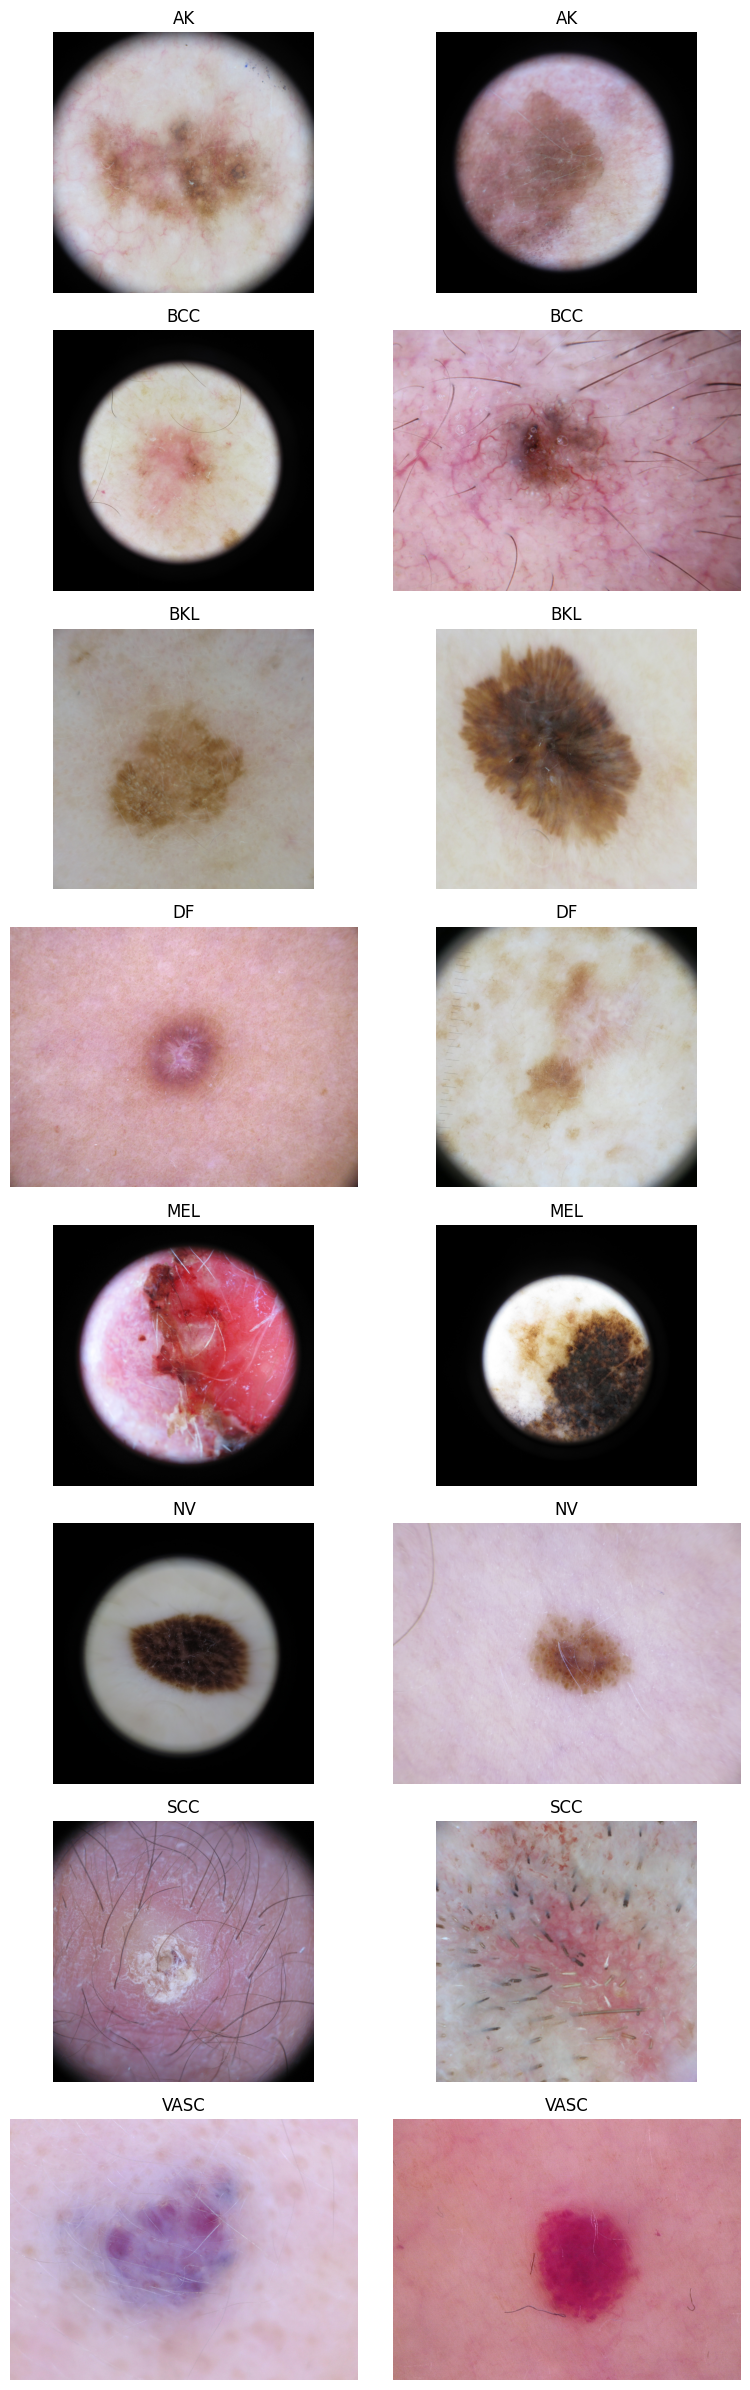

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ---------- Paths ----------
base_path = "/content/ISIC_2019"
# Auto-detect image directory
def find_image_dir(base_path):
    for root, dirs, files in os.walk(base_path):
        if any(f.endswith(".jpg") for f in files):
            return root
    return None

image_dir = find_image_dir(base_path)
print("✅ Image directory:", image_dir)

# ---------- Load CSV ----------
csv_files = [f for f in os.listdir(base_path) if f.endswith(".csv")]
print("CSV files:", csv_files)

csv_path = os.path.join(base_path, csv_files[0])  # assuming training CSV is first
df = pd.read_csv(csv_path)

# ---------- Convert one-hot to class label ----------
class_names = df.columns[1:]  # skip 'image' column
df['label'] = df[class_names].idxmax(axis=1)

# ---------- Group by class ----------
grouped = df.groupby('label')
num_classes = len(grouped)

# ---------- Create subplot ----------
fig, axes = plt.subplots(num_classes, 2, figsize=(8, num_classes * 3))
if num_classes == 1:
    axes = [axes]

# ---------- Loop through classes ----------
for i, (label, group) in enumerate(grouped):
    samples = group.sample(min(2, len(group)))  # 2 random images, safe for small classes

    for j, (_, row) in enumerate(samples.iterrows()):
        img_id = str(row['image']).strip()
        img_name = img_id + ".jpg"
        img_path = os.path.join(image_dir, img_name)

        if not os.path.exists(img_path):
            print(f"❌ Missing: {img_name}")
            continue

        # Load image with PIL
        img = Image.open(img_path).convert("RGB")

        # Show image
        axes[i][j].imshow(img)
        axes[i][j].axis('off')
        axes[i][j].set_title(label)

plt.tight_layout()
plt.show()

In [ ]:
for i,j,k in os.walk("/content/ISIC_2019"):
  print(i)
  print(j)
  print(k)

/content/ISIC_2019
['ISIC_2019_Training_Input']
['ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Metadata.csv']
/content/ISIC_2019/ISIC_2019_Training_Input
['ISIC_2019_Training_Input']
[]
/content/ISIC_2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input
[]
['ISIC_0034263.jpg', 'ISIC_0061725.jpg', 'ISIC_0069394.jpg', 'ISIC_0024412.jpg', 'ISIC_0030433.jpg', 'ISIC_0028894.jpg', 'ISIC_0071375.jpg', 'ISIC_0064114.jpg', 'ISIC_0027897.jpg', 'ISIC_0069591.jpg', 'ISIC_0032918.jpg', 'ISIC_0030658.jpg', 'ISIC_0029784.jpg', 'ISIC_0015945_downsampled.jpg', 'ISIC_0072180.jpg', 'ISIC_0032102.jpg', 'ISIC_0026209.jpg', 'ISIC_0000115_downsampled.jpg', 'ISIC_0062917.jpg', 'ISIC_0024597.jpg', 'ISIC_0055465.jpg', 'ISIC_0058896.jpg', 'ISIC_0060621.jpg', 'ISIC_0064424.jpg', 'ISIC_0062674.jpg', 'ISIC_0032886.jpg', 'ISIC_0030177.jpg', 'ISIC_0030842.jpg', 'ISIC_0027539.jpg', 'ISIC_0065747.jpg', 'ISIC_0026385.jpg', 'ISIC_0069604.jpg', 'ISIC_0025257.jpg', 'ISIC_0061302.jpg', 'ISIC_0068134.jpg', 'ISIC

# Preprocessing

In [ ]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.utils.data.sampler import WeightedRandomSampler
import torch

# -----------------------------
# Paths
# -----------------------------
base_path = "/content/ISIC_2019"
# Auto-detect image folder
image_dir = None
for root, dirs, files in os.walk(base_path):
    if any(f.endswith(".jpg") for f in files):
        image_dir = root
        break
assert image_dir is not None, "Image folder not found!"

# Use correct CSV (Training GroundTruth)
csv_path = os.path.join(base_path, "ISIC_2019_Training_GroundTruth.csv")
assert os.path.exists(csv_path), f"CSV not found at {csv_path}"

# -----------------------------
# Load CSV and prepare labels
# -----------------------------
df = pd.read_csv(csv_path)

# Convert one-hot to class index
class_names = df.columns[1:]  # skip 'image'
df['label'] = df[class_names].idxmax(axis=1)
label2idx = {cls:i for i, cls in enumerate(class_names)}
df['label_idx'] = df['label'].map(label2idx)

num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names.tolist()}")

# -----------------------------
# Transformations
# -----------------------------
# Research-ready transforms: Resize, ToTensor, Normalize
transform = T.Compose([
    T.Resize((224,224)),           # CNN + ViT standard input
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# -----------------------------
# Dataset Class
# -----------------------------
class ISICDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = str(row['image']).strip()
        img_path = os.path.join(self.image_dir, img_id + ".jpg")

        # Safe image loading
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row['label_idx'])
        return img, label

# -----------------------------
# Weighted Sampling for Class Imbalance
# -----------------------------
class_counts = df['label_idx'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = class_weights[torch.tensor(df['label_idx'].values)]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# -----------------------------
# DataLoader
# -----------------------------
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label_idx'], random_state=42
)

train_dataset = ISICDataset(train_df, image_dir, transform=transform)
val_dataset = ISICDataset(val_df, image_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)



Detected 9 classes: ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


# Defining Model

In [ ]:
import torch
import torch.nn as nn
import timm

class CNN_ViT_EarlyFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = timm.create_model('efficientnet_b0', pretrained=True, features_only=True)
        self.cnn_out_dim = self.cnn.feature_info[-1]['num_chs']

        self.vit = timm.create_model('deit_base_distilled_patch16_224', pretrained=True, num_classes=0)
        self.vit_out_dim = self.vit.embed_dim  # 768

        fused_dim = self.cnn_out_dim + self.vit_out_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)[-1]  # last feature map
        cnn_feat = nn.functional.adaptive_avg_pool2d(cnn_feat, 1).flatten(1)


        vit_feat = self.vit(x)

        # Early fusion
        fused = torch.cat([cnn_feat, vit_feat], dim=1)
        out = self.classifier(fused)
        return out

# GPU

In [ ]:
num_classes = len(class_names)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)
model = CNN_ViT_EarlyFusion(num_classes).to(device)

cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/349M [00:00<?, ?B/s]

# Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import copy
import os


save_dir = "/content/drive/MyDrive/ISIC19_Models"
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, "best_model_isic19.pth")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 10

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

        _, preds = torch.max(outputs, 1)
        train_preds.append(preds.detach().cpu())
        train_labels.append(labels.detach().cpu())

    train_loss /= len(train_loader.dataset)
    train_preds = torch.cat(train_preds)
    train_labels = torch.cat(train_labels)
    train_acc = accuracy_score(train_labels.numpy(), train_preds.numpy())

    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)

            _, preds = torch.max(outputs, 1)
            val_preds.append(preds.cpu())
            val_labels.append(labels.cpu())

    val_loss /= len(val_loader.dataset)
    val_preds = torch.cat(val_preds)
    val_labels = torch.cat(val_labels)
    val_acc = accuracy_score(val_labels.numpy(), val_preds.numpy())

    print(f"""
      Epoch {epoch+1}/{num_epochs}
      Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}
      Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}
""")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, best_model_path)

        print(f"Best model updated (Val Acc: {best_val_acc:.4f}) → saved")

model.load_state_dict(best_model_wts)
print(f"Training complete. Best Validation Accuracy: {best_val_acc:.4f}")


      Epoch 1/10
      Train Loss: 0.9241 | Train Acc: 0.6846
      Val   Loss: 0.6793 | Val   Acc: 0.7545

Best model updated (Val Acc: 0.7545) → saved

      Epoch 2/10
      Train Loss: 0.5639 | Train Acc: 0.8038
      Val   Loss: 0.5795 | Val   Acc: 0.7975

Best model updated (Val Acc: 0.7975) → saved

      Epoch 3/10
      Train Loss: 0.3360 | Train Acc: 0.8841
      Val   Loss: 0.5774 | Val   Acc: 0.8086

Best model updated (Val Acc: 0.8086) → saved

      Epoch 4/10
      Train Loss: 0.2024 | Train Acc: 0.9307
      Val   Loss: 0.6580 | Val   Acc: 0.8117

Best model updated (Val Acc: 0.8117) → saved

      Epoch 5/10
      Train Loss: 0.1267 | Train Acc: 0.9567
      Val   Loss: 0.7136 | Val   Acc: 0.8099


      Epoch 6/10
      Train Loss: 0.0888 | Train Acc: 0.9713
      Val   Loss: 0.7618 | Val   Acc: 0.8212

Best model updated (Val Acc: 0.8212) → saved

      Epoch 7/10
      Train Loss: 0.0801 | Train Acc: 0.9735
      Val   Loss: 0.7437 | Val   Acc: 0.8135


      Epoch

# Reload Model

In [ ]:
import torch

model_path = "/content/drive/MyDrive/ISIC19_Models/best_model_isic19.pth"

# Recreate model
num_classes = 9
model = CNN_ViT_EarlyFusion(num_classes)

# Load weights
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


# Inference

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Different Evaluation Matrices

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

Accuracy  : 0.8283
Precision : 0.8249
Recall    : 0.8283
F1-score  : 0.8254


# Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(class_names))),
    target_names=class_names
))



              precision    recall  f1-score   support

         MEL       0.77      0.72      0.74       904
          NV       0.87      0.93      0.90      2575
         BCC       0.85      0.84      0.84       665
          AK       0.63      0.55      0.59       173
         BKL       0.76      0.65      0.70       525
          DF       0.80      0.67      0.73        48
        VASC       0.92      0.88      0.90        51
         SCC       0.61      0.67      0.64       126
         UNK       0.00      0.00      0.00         0
       label       0.00      0.00      0.00         0
   label_idx       0.00      0.00      0.00         0

    accuracy                           0.83      5067
   macro avg       0.56      0.54      0.55      5067
weighted avg       0.82      0.83      0.83      5067



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

# Confusion-Matrix

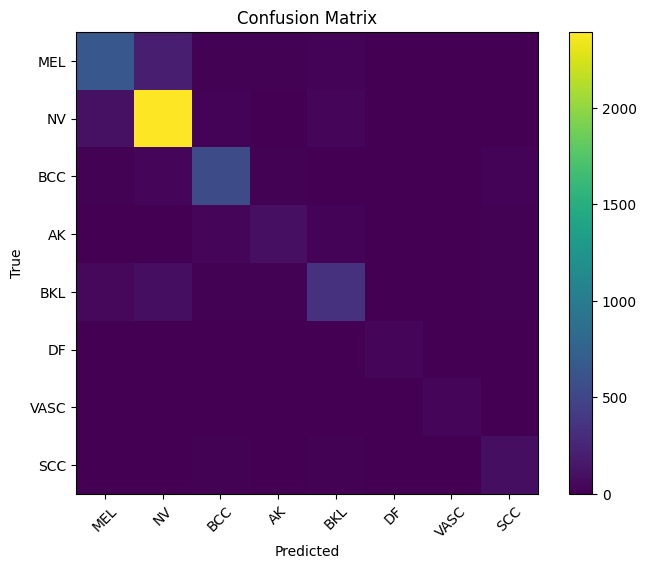

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(8), class_names[0:8], rotation=45)
plt.yticks(np.arange(8), class_names[0:8])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC-AUC Evaluation

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

y_true = np.array(all_labels)
y_score = np.array(all_probs)


present_classes = np.unique(y_true)

print("Classes used for ROC-AUC:", present_classes)


y_score_filtered = y_score[:, present_classes]


y_true_bin = label_binarize(y_true, classes=present_classes)

auc_macro = roc_auc_score(y_true_bin, y_score_filtered, average='macro')
auc_weighted = roc_auc_score(y_true_bin, y_score_filtered, average='weighted')

print("ROC-AUC(macro):", auc_macro)
print("ROC-AUC(weighted):", auc_weighted)

Classes used for ROC-AUC: [0 1 2 3 4 5 6 7]
ROC-AUC(macro): 0.9661545245680823
ROC-AUC(weighted): 0.9599766488032869
